
# D2D Hybrid Bonding Global Warpage Demo

这个 notebook 演示如何用 **Suhir-based multilayer warpage model with initial warpage** 计算一个 **D2D hybrid bonding stack** 的 released/global warpage。

模型输出：
- final common curvature \(\kappa\)
- total warpage / maximum bow \(W=\frac{|\kappa|L^2}{2}\)
- 每层 axial force per unit width \(F_i\)
- 每层 average in-plane stress \(\sigma_i=F_i/h_i\)

> 注意：这是 global die-stack warpage model，不计算 Cu pad 附近的 local peeling stress。



## 1. Model equations

For layer \(i=0,1,\dots,m\):

\[
E_i^0=\frac{E_i}{1-\nu_i},\qquad
\lambda_i=\frac{1}{E_i^0h_i}
\]

\[
a_i=\sum_{j=0}^{i}h_j-\frac{h_0+h_i}{2}
\]

\[
b_i=\sum_{j=0}^{i}h_j\kappa_j^0-\frac{h_0\kappa_0^0+h_i\kappa_i^0}{2}
\]

\[
\Delta\alpha_i=\alpha_i-\alpha_0
\]

\[
F_i=\frac{1}{\lambda_i}
\left[
(\Delta\alpha_i-s_\alpha)\Delta T
-(a_i-s_a)\kappa
+(b_i-s_b)
\right]
\]

Moment equilibrium:

\[
\sum_iF_ia_i+\sum_iD_i(\kappa-\kappa_i^0)=0,
\qquad
D_i=\frac{E_i^0h_i^3}{12}
\]

Final bow:

\[
W=\frac{|\kappa|L^2}{2}
\]


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass
class Layer:
    name: str
    h: float          # thickness [m]
    E: float          # Young's modulus [Pa]
    nu: float         # Poisson's ratio
    alpha: float      # effective CTE [1/K]
    kappa0: float = 0.0 # initial curvature before bonding [1/m]

def bow_to_curvature(W, L):
    """Convert center-to-edge bow W [m] over half-length L [m] to curvature [1/m]."""
    return 2.0 * W / (L**2)

def curvature_to_bow(kappa, L):
    """Convert curvature [1/m] to center-to-edge bow magnitude [m]."""
    return np.abs(kappa) * L**2 / 2.0

def compute_multilayer_warpage(layers, delta_T, L):
    """
    Suhir-based multilayer warpage model with initial warpage.

    layer 0 is the reference/bottom layer.
    delta_T uses a consistent sign convention, e.g. T_final - T_anneal.
    """
    h = np.array([layer.h for layer in layers], dtype=float)
    E = np.array([layer.E for layer in layers], dtype=float)
    nu = np.array([layer.nu for layer in layers], dtype=float)
    alpha = np.array([layer.alpha for layer in layers], dtype=float)
    kappa0 = np.array([layer.kappa0 for layer in layers], dtype=float)
    names = [layer.name for layer in layers]

    E0 = E / (1.0 - nu)             # biaxial modulus [Pa]
    lam = 1.0 / (E0 * h)            # axial compliance [m/N]
    inv_lam = 1.0 / lam             # axial stiffness per unit width [N/m]

    # a_i: distance from mid-plane of layer 0 to mid-plane of layer i
    a = np.zeros_like(h)
    for i in range(len(h)):
        a[i] = np.sum(h[:i+1]) - (h[0] + h[i]) / 2.0

    # b_i: initial-curvature geometry term
    b = np.zeros_like(h)
    for i in range(len(h)):
        b[i] = np.sum(h[:i+1] * kappa0[:i+1]) - (h[0]*kappa0[0] + h[i]*kappa0[i]) / 2.0

    delta_alpha = alpha - alpha[0]

    denom = np.sum(inv_lam)
    s_alpha = np.sum(delta_alpha * inv_lam) / denom
    s_a = np.sum(a * inv_lam) / denom
    s_b = np.sum(b * inv_lam) / denom

    D = E0 * h**3 / 12.0

    M_T = np.sum(a * inv_lam * (delta_alpha - s_alpha) * delta_T)
    M_b = np.sum(a * inv_lam * (b - s_b))
    K_a = np.sum(a * inv_lam * (a - s_a))
    K_D = np.sum(D)
    M_D0 = np.sum(D * kappa0)

    kappa = (M_D0 - M_T - M_b) / (K_D - K_a)
    W = curvature_to_bow(kappa, L)

    F = inv_lam * ((delta_alpha - s_alpha) * delta_T - (a - s_a) * kappa + (b - s_b))
    sigma = F / h

    table = pd.DataFrame({
        "layer": names,
        "h_um": h * 1e6,
        "E_GPa": E / 1e9,
        "nu": nu,
        "E0_GPa": E0 / 1e9,
        "alpha_ppm_per_K": alpha * 1e6,
        "kappa0_1_per_m": kappa0,
        "initial_bow_um": curvature_to_bow(kappa0, L) * 1e6,
        "a_um": a * 1e6,
        "b_strain_like": b,
        "D_Nm": D,
        "F_N_per_m": F,
        "sigma_MPa": sigma / 1e6,
    })

    return {
        "kappa_1_per_m": kappa,
        "warpage_m": W,
        "warpage_um": W * 1e6,
        "table": table,
        "terms": {
            "s_alpha": s_alpha,
            "s_a": s_a,
            "s_b": s_b,
            "M_T": M_T,
            "M_b": M_b,
            "K_a": K_a,
            "K_D": K_D,
            "M_D0": M_D0,
            "delta_T": delta_T,
            "L": L,
        }
    }



## 2. D2D example setup

设置一个 \(10\,\mathrm{mm}\times10\,\mathrm{mm}\) D2D stack：

- bottom die: \(50\,\mu m\)
- top die: \(50\,\mu m\)
- die half-length: \(L=5\,mm\)
- anneal temperature: \(250^\circ C\)
- final temperature: \(25^\circ C\)
- \(\Delta T=T_\mathrm{final}-T_\mathrm{anneal}=-225K\)

为了让 demo 有非零结果，这里让 top die 的 effective CTE 略高，并加入 initial bow。  
如果两层完全一样且 initial bow 都为 0，模型会给出 \(W=0\)。


In [2]:

# Geometry
die_size = 10e-3   # [m], 10 mm
L = die_size / 2   # half-length [m]

# Process thermal cycle
T_anneal = 250.0 + 273.15  # [K]
T_final  = 25.0 + 273.15   # [K]
delta_T = T_final - T_anneal

# Material parameters
E_Si = 130e9       # [Pa]
nu_Si = 0.28
alpha_Si = 2.6e-6 # [1/K]

# Effective die parameters
# Top die has a slightly higher effective CTE due to BEOL/Cu contribution.
alpha_bottom_eff = 2.60e-6
alpha_top_eff    = 2.75e-6

# Die thicknesses
h_bottom = 50e-6
h_top    = 50e-6

# Initial bow settings
# Positive/negative signs are curvature convention.
# If top die free bow is measured before flipping, you may need to change sign.
bottom_initial_bow = 0.0e-6  # [m]
top_initial_bow    = 2.0e-6  # [m], example over 10 mm die

kappa_bottom0 = bow_to_curvature(bottom_initial_bow, L)
kappa_top0    = bow_to_curvature(top_initial_bow, L)

layers_d2d = [
    Layer("bottom_die", h_bottom, E_Si, nu_Si, alpha_bottom_eff, kappa_bottom0),
    Layer("top_die",    h_top,    E_Si, nu_Si, alpha_top_eff,    kappa_top0),
]

results = compute_multilayer_warpage(layers_d2d, delta_T, L)

print(f"delta_T = {delta_T:.1f} K")
print(f"Final curvature kappa = {results['kappa_1_per_m']:.4e} 1/m")
print(f"Total global warpage W = {results['warpage_um']:.4f} um")
results["table"]


delta_T = -225.0 K
Final curvature kappa = -9.3250e-01 1/m
Total global warpage W = 11.6562 um


,layer,h_um,E_GPa,nu,E0_GPa,alpha_ppm_per_K,kappa0_1_per_m,initial_bow_um,a_um,b_strain_like,D_Nm,F_N_per_m,sigma_MPa
0,bottom_die,50.0,130.0,0.28,180.555556,2.60,0.00,0.0,0.0,0.000000,0.001881,-76.171875,-1.523437
1,top_die,50.0,130.0,0.28,180.555556,2.75,0.16,2.0,50.0,0.000004,0.001881,76.171875,1.523437



## 3. Plot released stack profile

这里画出 released stack 的 parabolic global warpage profile：

\[
w(x)=\frac{\kappa x^2}{2}
\]


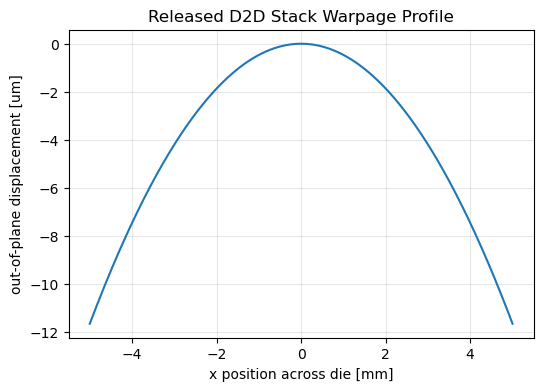

In [4]:

kappa = results["kappa_1_per_m"]

x = np.linspace(-L, L, 401)
w = 0.5 * kappa * x**2
w_centered = w - w[len(w)//2]

plt.figure(figsize=(6, 4))
plt.plot(x * 1e3, w_centered * 1e6)
plt.xlabel("x position across die [mm]")
plt.ylabel("out-of-plane displacement [um]")
plt.title("Released D2D Stack Warpage Profile")
plt.grid(True, alpha=0.3)
plt.show()



## 4. Parameter sweep: top die initial bow

下面 sweep top die initial bow，看看 initial warpage 对 final stack warpage 的影响。


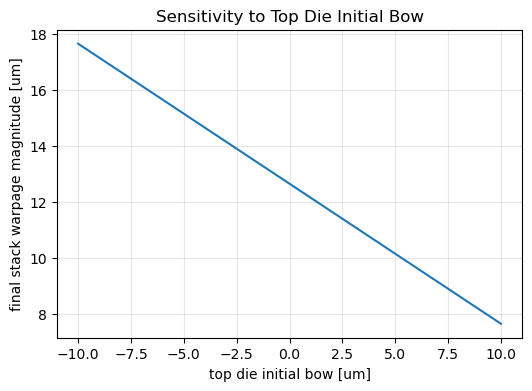

In [5]:

top_bow_sweep_um = np.linspace(-10, 10, 81)
warpage_sweep_um = []

for top_bow_um in top_bow_sweep_um:
    layers = [
        Layer("bottom_die", h_bottom, E_Si, nu_Si, alpha_bottom_eff, kappa_bottom0),
        Layer("top_die", h_top, E_Si, nu_Si, alpha_top_eff, bow_to_curvature(top_bow_um * 1e-6, L)),
    ]
    res = compute_multilayer_warpage(layers, delta_T, L)
    warpage_sweep_um.append(res["warpage_um"])

plt.figure(figsize=(6, 4))
plt.plot(top_bow_sweep_um, warpage_sweep_um)
plt.xlabel("top die initial bow [um]")
plt.ylabel("final stack warpage magnitude [um]")
plt.title("Sensitivity to Top Die Initial Bow")
plt.grid(True, alpha=0.3)
plt.show()



## 5. Parameter sweep: effective CTE mismatch

下面 sweep top die effective CTE。  
如果 top/bottom die 的 effective CTE 完全相同，并且 initial warpage 为 0，那么 thermal-mismatch-driven global warpage 会接近 0。


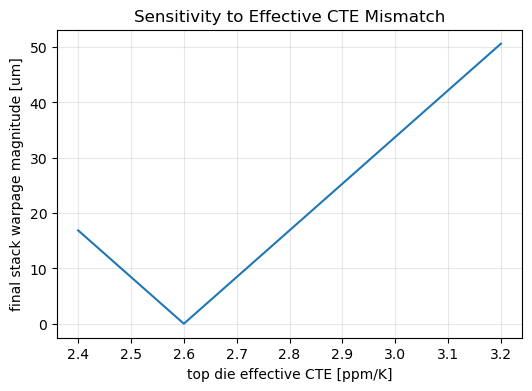

In [6]:

top_alpha_sweep_ppm = np.linspace(2.4, 3.2, 81)
warpage_alpha_sweep_um = []

# Set initial bow to zero to isolate CTE mismatch effect
for alpha_top_ppm in top_alpha_sweep_ppm:
    layers = [
        Layer("bottom_die", h_bottom, E_Si, nu_Si, alpha_bottom_eff, 0.0),
        Layer("top_die", h_top, E_Si, nu_Si, alpha_top_ppm * 1e-6, 0.0),
    ]
    res = compute_multilayer_warpage(layers, delta_T, L)
    warpage_alpha_sweep_um.append(res["warpage_um"])

plt.figure(figsize=(6, 4))
plt.plot(top_alpha_sweep_ppm, warpage_alpha_sweep_um)
plt.xlabel("top die effective CTE [ppm/K]")
plt.ylabel("final stack warpage magnitude [um]")
plt.title("Sensitivity to Effective CTE Mismatch")
plt.grid(True, alpha=0.3)
plt.show()



## 6. Sanity check: identical die, no initial bow

If two dies are identical and initially flat:

\[
\alpha_0=\alpha_1,\qquad \kappa_0^0=\kappa_1^0=0
\]

then the model should give nearly zero global warpage.


In [7]:

layers_identical = [
    Layer("bottom_die", h_bottom, E_Si, nu_Si, alpha_Si, 0.0),
    Layer("top_die",    h_top,    E_Si, nu_Si, alpha_Si, 0.0),
]
res_identical = compute_multilayer_warpage(layers_identical, delta_T, L)

print(f"Identical D2D stack curvature = {res_identical['kappa_1_per_m']:.4e} 1/m")
print(f"Identical D2D stack warpage = {res_identical['warpage_um']:.4e} um")
res_identical["table"]


Identical D2D stack curvature = -0.0000e+00 1/m
Identical D2D stack warpage = 0.0000e+00 um


,layer,h_um,E_GPa,nu,E0_GPa,alpha_ppm_per_K,kappa0_1_per_m,initial_bow_um,a_um,b_strain_like,D_Nm,F_N_per_m,sigma_MPa
0,bottom_die,50.0,130.0,0.28,180.555556,2.6,0.0,0.0,0.0,0.0,0.001881,0.0,0.0
1,top_die,50.0,130.0,0.28,180.555556,2.6,0.0,0.0,50.0,0.0,0.001881,0.0,0.0
